# PINN del vórtice con trayectorias en coordenadas polares

Esta versión mantiene la idea del Problema 4 de `E1-TAPIA-ORDOÑEZ.ipynb`, pero adapta el entrenamiento a las tres trayectorias experimentales.

Cambios principales:

1. Las trayectorias se representan internamente mediante radio y ángulo, en lugar de x e y directamente.
2. Se impone exactamente la posición inicial de cada trayectoria.
3. Se usan variables y pérdidas adimensionalizadas.
4. Se usa doble precisión para mejorar las derivadas de la PINN.
5. Se agrega un diagnóstico cinemático antes de imponer Burgers.
6. El entrenamiento se hace en dos etapas: primero datos, después datos + física.
7. La importancia de la física aumenta gradualmente para no destruir el ajuste previo a los datos.
8. Se limita cuánto puede desplazarse el centro aprendido del vórtice.


## 1. Librerías y configuración


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch


# PINNs suelen beneficiarse de doble precisión
torch.set_default_dtype(torch.float64)

torch.manual_seed(1234)
np.random.seed(1234)


device = torch.device(
    "cuda:0" if torch.cuda.is_available() else "cpu"
)

print("Dispositivo:", device)
print("dtype:", torch.get_default_dtype())


plt.rcParams.update({
    "figure.figsize": (8, 7),
    "axes.grid": True,
    "font.family": "STIXGeneral",
    "mathtext.fontset": "cm",
    "axes.labelsize": 15,
    "axes.titlesize": 18,
    "legend.fontsize": 11,
})


Dispositivo: cpu
dtype: torch.float64


## 2. Cargar las tres trayectorias


In [2]:
CARPETA = Path(
    r"C:\Users\user\Desktop\Labo5\1_Fluidos\datos\crudos"
)


ARCHIVOS = [
    CARPETA / "trayectoria1_PINN.csv",
    CARPETA / "trayectoria2_PINN.csv",
    CARPETA / "trayectoria3_PINN.csv",
]


dfs = []


for archivo in ARCHIVOS:

    df = pd.read_csv(archivo)

    df = (
        df
        .dropna(
            subset=["t_s", "x_m", "y_m"]
        )
        .sort_values("t_s")
        .reset_index(drop=True)
    )

    if len(df) < 10:
        raise RuntimeError(
            f"Muy pocos datos en {archivo.name}"
        )

    dfs.append(df)


for i, df in enumerate(dfs, start=1):

    print(
        f"Trayectoria {i}: "
        f"{len(df)} puntos | "
        f"T = {df['t_s'].max():.3f} s"
    )


Trayectoria 1: 232 puntos | T = 3.855 s
Trayectoria 2: 157 puntos | T = 2.603 s
Trayectoria 3: 241 puntos | T = 4.005 s


## 3. Trayectorias experimentales


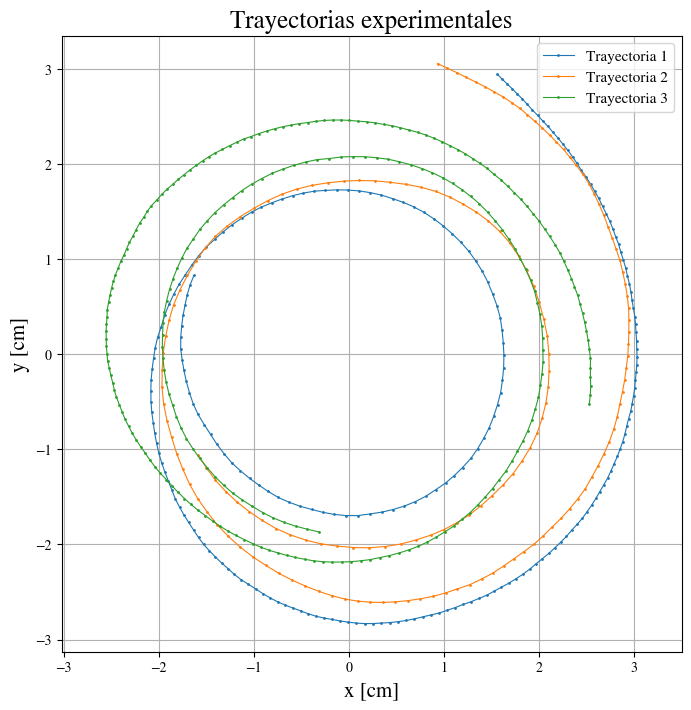

In [3]:
fig, ax = plt.subplots(
    figsize=(8, 8)
)


for i, df in enumerate(
    dfs,
    start=1
):

    ax.plot(
        100 * df["x_m"],
        100 * df["y_m"],
        ".-",
        ms=2,
        lw=0.8,
        label=f"Trayectoria {i}"
    )


ax.set_xlabel("x [cm]")
ax.set_ylabel("y [cm]")
ax.set_title("Trayectorias experimentales")
ax.axis("equal")
ax.legend()

plt.show()


## 4. Diagnóstico cinemático antes de usar una PINN

Esta sección no entrena nada.

Se suavizan levemente las posiciones únicamente para estimar derivadas numéricas y revisar si las trayectorias son compatibles, al menos cualitativamente, con un campo estacionario de tipo Burgers.

Los datos suavizados de esta sección NO se utilizan después para entrenar la red.


In [4]:
def suavizado_movil(a, ventana=7):

    return (
        pd.Series(a)
        .rolling(
            ventana,
            center=True,
            min_periods=1
        )
        .mean()
        .to_numpy()
    )


def diagnostico_trayectoria(
    df,
    ventana=7
):

    t = df["t_s"].to_numpy()

    x = df["x_m"].to_numpy()
    y = df["y_m"].to_numpy()


    xs = suavizado_movil(
        x,
        ventana
    )

    ys = suavizado_movil(
        y,
        ventana
    )


    vx = np.gradient(
        xs,
        t
    )

    vy = np.gradient(
        ys,
        t
    )


    r = np.sqrt(
        xs**2 + ys**2
    )

    r_seguro = (
        r + 1e-12
    )


    vr = (
        xs * vx
        + ys * vy
    ) / r_seguro


    vt = (
        -ys * vx
        + xs * vy
    ) / r_seguro


    rapidez = np.sqrt(
        vx**2 + vy**2
    )


    theta = np.unwrap(
        np.arctan2(
            ys,
            xs
        )
    )


    return {
        "t": t,
        "x": xs,
        "y": ys,
        "r": r,
        "theta": theta,
        "vx": vx,
        "vy": vy,
        "vr": vr,
        "vt": vt,
        "rapidez": rapidez,
    }


diagnosticos = [
    diagnostico_trayectoria(df)
    for df in dfs
]


### 4.1 Radio y ángulo en función del tiempo


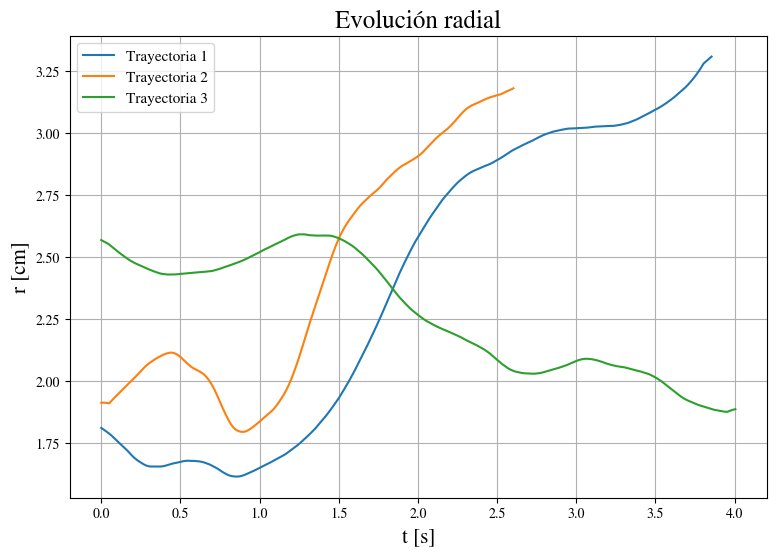

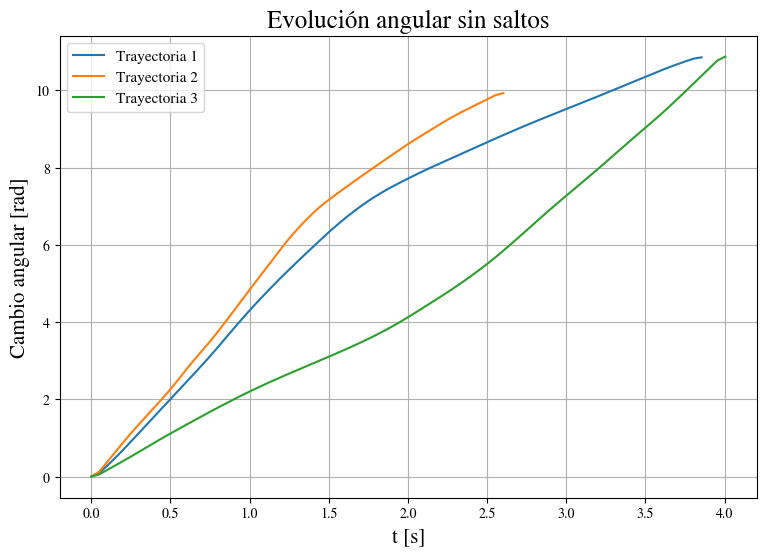

In [5]:
fig, ax = plt.subplots(
    figsize=(9, 6)
)


for i, d in enumerate(
    diagnosticos,
    start=1
):

    ax.plot(
        d["t"],
        100 * d["r"],
        label=f"Trayectoria {i}"
    )


ax.set_xlabel("t [s]")
ax.set_ylabel("r [cm]")
ax.set_title("Evolución radial")

ax.legend()

plt.show()


fig, ax = plt.subplots(
    figsize=(9, 6)
)


for i, d in enumerate(
    diagnosticos,
    start=1
):

    delta_theta = (
        d["theta"]
        - d["theta"][0]
    )

    ax.plot(
        d["t"],
        delta_theta,
        label=f"Trayectoria {i}"
    )


ax.set_xlabel("t [s]")
ax.set_ylabel("Cambio angular [rad]")
ax.set_title("Evolución angular sin saltos")

ax.legend()

plt.show()


### 4.2 Velocidad radial y tangencial estimadas directamente de las trayectorias


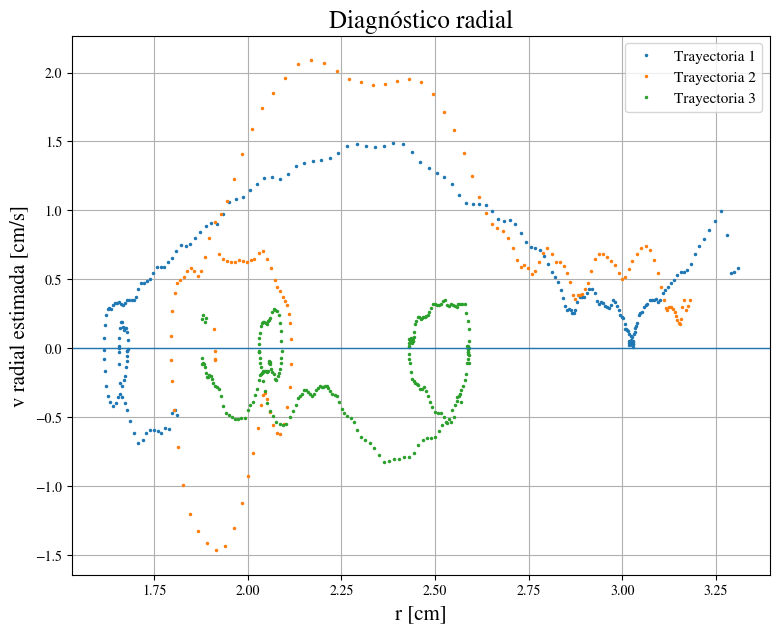

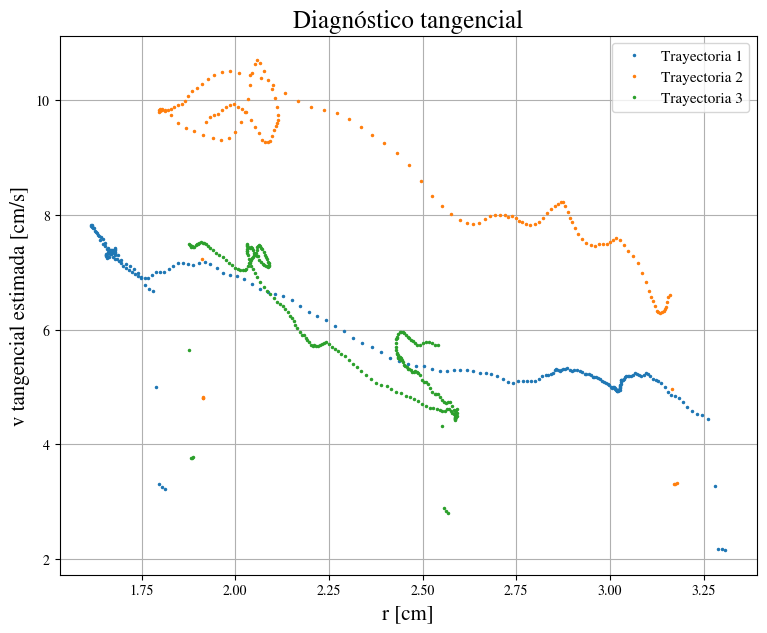

In [6]:
fig, ax = plt.subplots(
    figsize=(9, 7)
)


for i, d in enumerate(
    diagnosticos,
    start=1
):

    ax.plot(
        100 * d["r"],
        100 * d["vr"],
        ".",
        ms=3,
        label=f"Trayectoria {i}"
    )


ax.axhline(
    0,
    linewidth=1
)

ax.set_xlabel("r [cm]")
ax.set_ylabel("v radial estimada [cm/s]")
ax.set_title("Diagnóstico radial")

ax.legend()

plt.show()


fig, ax = plt.subplots(
    figsize=(9, 7)
)


for i, d in enumerate(
    diagnosticos,
    start=1
):

    ax.plot(
        100 * d["r"],
        100 * d["vt"],
        ".",
        ms=3,
        label=f"Trayectoria {i}"
    )


ax.set_xlabel("r [cm]")
ax.set_ylabel("v tangencial estimada [cm/s]")
ax.set_title("Diagnóstico tangencial")

ax.legend()

plt.show()


### 4.3 Resumen automático de consistencia


In [7]:
rapideces = []


for i, d in enumerate(
    diagnosticos,
    start=1
):

    vr = d["vr"]

    fraccion_salida = np.mean(
        vr > 0
    )

    mediana_vr = np.median(
        vr
    )

    mediana_vt = np.median(
        d["vt"]
    )

    rapideces.append(
        d["rapidez"]
    )


    print()
    print("=" * 55)
    print(f"TRAYECTORIA {i}")
    print("=" * 55)

    print(
        f"r inicial = "
        f"{100*d['r'][0]:.3f} cm"
    )

    print(
        f"r final = "
        f"{100*d['r'][-1]:.3f} cm"
    )

    print(
        f"mediana v_r = "
        f"{100*mediana_vr:.3f} cm/s"
    )

    print(
        f"mediana v_t = "
        f"{100*mediana_vt:.3f} cm/s"
    )

    print(
        f"porcentaje de puntos con v_r > 0 = "
        f"{100*fraccion_salida:.1f} %"
    )


    if fraccion_salida > 0.65:

        print(
            "ADVERTENCIA: esta trayectoria es "
            "predominantemente radialmente saliente "
            "respecto del origen actual."
        )


U_SCALE = float(
    np.quantile(
        np.concatenate(rapideces),
        0.90
    )
)


U_SCALE = max(
    U_SCALE,
    0.02
)


print()
print("=" * 55)
print("ESCALA DE VELOCIDAD PARA LA PINN")
print("=" * 55)

print(
    f"U_SCALE = {U_SCALE:.5f} m/s"
)



TRAYECTORIA 1
r inicial = 1.812 cm
r final = 3.308 cm
mediana v_r = 0.328 cm/s
mediana v_t = 5.313 cm/s
porcentaje de puntos con v_r > 0 = 83.2 %
ADVERTENCIA: esta trayectoria es predominantemente radialmente saliente respecto del origen actual.

TRAYECTORIA 2
r inicial = 1.913 cm
r final = 3.180 cm
mediana v_r = 0.548 cm/s
mediana v_t = 9.278 cm/s
porcentaje de puntos con v_r > 0 = 80.9 %
ADVERTENCIA: esta trayectoria es predominantemente radialmente saliente respecto del origen actual.

TRAYECTORIA 3
r inicial = 2.569 cm
r final = 1.887 cm
mediana v_r = -0.185 cm/s
mediana v_t = 5.778 cm/s
porcentaje de puntos con v_r > 0 = 32.0 %

ESCALA DE VELOCIDAD PARA LA PINN
U_SCALE = 0.09608 m/s


### 4.4 Búsqueda de revisitas espaciales

Para un campo estacionario autónomo, si una trayectoria vuelve prácticamente al mismo punto en dos tiempos distintos, la velocidad local debería ser prácticamente la misma.

Este diagnóstico busca pares de puntos espacialmente cercanos pero suficientemente separados en el tiempo.


In [8]:
def diagnostico_revisita(
    d,
    separacion_temporal_min=0.5,
    max_puntos=600
):

    n = len(
        d["t"]
    )


    if n > max_puntos:

        idx = np.linspace(
            0,
            n - 1,
            max_puntos,
            dtype=int
        )

    else:

        idx = np.arange(
            n
        )


    t = d["t"][idx]

    P = np.column_stack(
        (
            d["x"][idx],
            d["y"][idx]
        )
    )

    V = np.column_stack(
        (
            d["vx"][idx],
            d["vy"][idx]
        )
    )


    dif_P = (
        P[:, None, :]
        - P[None, :, :]
    )

    dist = np.linalg.norm(
        dif_P,
        axis=2
    )


    dif_t = np.abs(
        t[:, None]
        - t[None, :]
    )


    mascara = (
        dif_t
        >= separacion_temporal_min
    )


    dist_valida = np.where(
        mascara,
        dist,
        np.inf
    )


    plano = np.argmin(
        dist_valida
    )

    i, j = np.unravel_index(
        plano,
        dist_valida.shape
    )


    distancia = dist_valida[
        i,
        j
    ]


    dv = np.linalg.norm(
        V[i] - V[j]
    )


    return {
        "distancia": distancia,
        "dv": dv,
        "t1": t[i],
        "t2": t[j],
    }


for i, d in enumerate(
    diagnosticos,
    start=1
):

    rev = diagnostico_revisita(
        d
    )

    print()
    print(
        f"Trayectoria {i}: "
        f"revisita más cercana = "
        f"{1000*rev['distancia']:.3f} mm"
    )

    print(
        f"  tiempos = "
        f"{rev['t1']:.3f} s y "
        f"{rev['t2']:.3f} s"
    )

    print(
        f"  diferencia de velocidades = "
        f"{100*rev['dv']:.3f} cm/s"
    )


    if (
        rev["distancia"] < 1e-3
        and
        rev["dv"] > 0.02
    ):

        print(
            "  ADVERTENCIA: hay una revisita "
            "muy cercana con velocidades distintas."
        )



Trayectoria 1: revisita más cercana = 1.079 mm
  tiempos = 0.000 s y 1.485 s
  diferencia de velocidades = 4.209 cm/s

Trayectoria 2: revisita más cercana = 2.286 mm
  tiempos = 0.000 s y 1.268 s
  diferencia de velocidades = 5.794 cm/s

Trayectoria 3: revisita más cercana = 3.151 mm
  tiempos = 2.186 s y 4.005 s
  diferencia de velocidades = 2.038 cm/s


## 5. Preparar los datos en coordenadas polares

La representación polar se utiliza solo para que la red aprenda trayectorias espiraladas con mayor facilidad.

El campo físico de Burgers se sigue evaluando finalmente en coordenadas cartesianas.


In [9]:
datos_torch = []


# Escala espacial global
todos_radios = []


for df in dfs:

    x = df["x_m"].to_numpy()
    y = df["y_m"].to_numpy()

    todos_radios.append(
        np.sqrt(
            x**2 + y**2
        )
    )


R_SCALE = float(
    np.quantile(
        np.concatenate(todos_radios),
        0.95
    )
)


R_SCALE = max(
    R_SCALE,
    0.01
)


# Primero calculamos el máximo cambio angular
delta_thetas_numpy = []


for df in dfs:

    theta = np.unwrap(
        np.arctan2(
            df["y_m"].to_numpy(),
            df["x_m"].to_numpy()
        )
    )

    delta_theta = (
        theta
        - theta[0]
    )

    delta_thetas_numpy.append(
        delta_theta
    )


THETA_SCALE = max(
    np.max(
        np.abs(delta_theta)
    )
    for delta_theta
    in delta_thetas_numpy
)


THETA_SCALE = max(
    float(THETA_SCALE),
    2 * np.pi
)


print(
    f"R_SCALE = {R_SCALE:.5f} m"
)

print(
    f"THETA_SCALE = {THETA_SCALE:.4f} rad"
)


for df, delta_theta_np in zip(
    dfs,
    delta_thetas_numpy
):

    t_np = df["t_s"].to_numpy()

    x_np = df["x_m"].to_numpy()
    y_np = df["y_m"].to_numpy()


    r_np = np.sqrt(
        x_np**2
        + y_np**2
    )


    theta_np = np.unwrap(
        np.arctan2(
            y_np,
            x_np
        )
    )


    theta_inicial = float(
        theta_np[0]
    )

    r_inicial = float(
        r_np[0]
    )


    t = torch.tensor(
        t_np,
        device=device
    ).view(-1, 1)


    X = torch.tensor(
        np.column_stack(
            (
                x_np,
                y_np
            )
        ),
        device=device
    )


    r = torch.tensor(
        r_np,
        device=device
    ).view(-1, 1)


    delta_theta = torch.tensor(
        delta_theta_np,
        device=device
    ).view(-1, 1)


    T = float(
        t_np.max()
    )


    tau = (
        2 * t / T
        - 1
    )


    datos_torch.append({
        "tau": tau,
        "X": X,
        "r": r,
        "delta_theta": delta_theta,
        "theta_inicial": theta_inicial,
        "r_inicial": r_inicial,
        "T": T,
    })


R_SCALE = 0.03126 m
THETA_SCALE = 11.0339 rad


## 6. Red neuronal para cada trayectoria


In [10]:
class MLP(torch.nn.Module):

    def __init__(
        self,
        sizes
    ):

        super().__init__()

        self.layers = (
            torch.nn.ModuleList()
        )


        for i in range(
            len(sizes) - 1
        ):

            layer = torch.nn.Linear(
                sizes[i],
                sizes[i + 1]
            )

            # Inicialización Xavier:
            # suele funcionar bien con tanh
            torch.nn.init.xavier_normal_(
                layer.weight
            )

            torch.nn.init.zeros_(
                layer.bias
            )

            self.layers.append(
                layer
            )


    def forward(
        self,
        x
    ):

        h = x


        for layer in self.layers[:-1]:

            h = torch.tanh(
                layer(h)
            )


        return self.layers[-1](
            h
        )


## 7. Transformación polar con condición inicial exacta

La red no aprende directamente la posición inicial.

La construcción garantiza que, en el primer instante, la trayectoria neuronal coincida exactamente con el primer dato experimental.


In [11]:
def salida_trayectoria(
    pinn,
    tau,
    datos
):

    salida = pinn(
        tau
    )


    # s vale 0 al inicio y 1 al final
    s = (
        tau + 1
    ) / 2


    # Condición inicial exacta
    r = (
        datos["r_inicial"]
        + s
        * R_SCALE
        * salida[:, 0:1]
    )


    delta_theta = (
        s
        * THETA_SCALE
        * salida[:, 1:2]
    )


    theta = (
        datos["theta_inicial"]
        + delta_theta
    )


    x = (
        r
        * torch.cos(theta)
    )


    y = (
        r
        * torch.sin(theta)
    )


    X = torch.cat(
        (
            x,
            y
        ),
        dim=1
    )


    return (
        X,
        r,
        delta_theta
    )


## 8. Crear las tres redes


In [12]:
pinns = torch.nn.ModuleList([
    MLP([1, 80, 80, 80, 80, 2]),
    MLP([1, 80, 80, 80, 80, 2]),
    MLP([1, 80, 80, 80, 80, 2]),
]).to(device)


print(pinns)


ModuleList(
  (0-2): 3 x MLP(
    (layers): ModuleList(
      (0): Linear(in_features=1, out_features=80, bias=True)
      (1-3): 3 x Linear(in_features=80, out_features=80, bias=True)
      (4): Linear(in_features=80, out_features=2, bias=True)
    )
  )
)


## 9. Etapa 1: preentrenamiento solamente con datos

La pérdida combina error radial, error angular y un término cartesiano auxiliar.

Se usa AdamW, reducción automática del learning rate y recorte de gradientes.


In [13]:
optimizer_datos = torch.optim.AdamW(
    pinns.parameters(),
    lr=1e-3,
    weight_decay=1e-8
)


scheduler_datos = (
    torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_datos,
        mode="min",
        factor=0.5,
        patience=1000,
        min_lr=1e-5
    )
)


ITERACIONES_DATOS = 20000


loss_pre = []
loss_pre_individual = [
    [],
    [],
    []
]


for epoch in range(
    ITERACIONES_DATOS
):

    optimizer_datos.zero_grad()

    perdida_total = 0.0

    perdidas_i = []


    for pinn, datos in zip(
        pinns,
        datos_torch
    ):

        X_pred, r_pred, delta_theta_pred = (
            salida_trayectoria(
                pinn,
                datos["tau"],
                datos
            )
        )


        error_r = torch.mean(
            (
                (
                    r_pred
                    - datos["r"]
                )
                / R_SCALE
            )**2
        )


        error_theta = torch.mean(
            (
                (
                    delta_theta_pred
                    - datos["delta_theta"]
                )
                / THETA_SCALE
            )**2
        )


        error_xy = torch.mean(
            (
                (
                    X_pred
                    - datos["X"]
                )
                / R_SCALE
            )**2
        )


        perdida_i = (
            error_r
            + error_theta
            + 0.5 * error_xy
        )


        perdida_total = (
            perdida_total
            + perdida_i
        )


        perdidas_i.append(
            perdida_i
        )


    perdida_total = (
        perdida_total
        / len(pinns)
    )


    perdida_total.backward()


    torch.nn.utils.clip_grad_norm_(
        pinns.parameters(),
        max_norm=5.0
    )


    optimizer_datos.step()


    scheduler_datos.step(
        perdida_total.detach()
    )


    loss_pre.append(
        perdida_total.detach()
        .cpu()
        .item()
    )


    for j, perdida_i in enumerate(
        perdidas_i
    ):

        loss_pre_individual[j].append(
            perdida_i.detach()
            .cpu()
            .item()
        )


    if epoch % 1000 == 0:

        lr_actual = (
            optimizer_datos
            .param_groups[0]["lr"]
        )

        print(
            f"Época {epoch:5d} | "
            f"Loss = "
            f"{perdida_total.item():.3e} | "
            f"lr = {lr_actual:.2e}"
        )


Época     0 | Loss = 7.293e-01 | lr = 1.00e-03
Época  1000 | Loss = 4.281e-02 | lr = 1.00e-03
Época  2000 | Loss = 3.389e-04 | lr = 1.00e-03
Época  3000 | Loss = 2.038e-04 | lr = 1.00e-03
Época  4000 | Loss = 1.179e-03 | lr = 1.00e-03
Época  5000 | Loss = 8.163e-05 | lr = 1.00e-03
Época  6000 | Loss = 6.161e-05 | lr = 1.00e-03
Época  7000 | Loss = 5.807e-05 | lr = 1.00e-03
Época  8000 | Loss = 1.252e-03 | lr = 1.00e-03
Época  9000 | Loss = 5.352e-05 | lr = 1.00e-03
Época 10000 | Loss = 8.626e-05 | lr = 1.00e-03
Época 11000 | Loss = 6.658e-05 | lr = 1.00e-03
Época 12000 | Loss = 1.114e-04 | lr = 1.00e-03
Época 13000 | Loss = 3.987e-04 | lr = 1.00e-03
Época 14000 | Loss = 3.178e-05 | lr = 1.00e-03
Época 15000 | Loss = 7.986e-05 | lr = 1.00e-03
Época 16000 | Loss = 7.248e-05 | lr = 1.00e-03
Época 17000 | Loss = 2.072e-04 | lr = 1.00e-03
Época 18000 | Loss = 2.920e-05 | lr = 1.00e-03
Época 19000 | Loss = 2.691e-05 | lr = 1.00e-03


## 10. Evolución del preentrenamiento


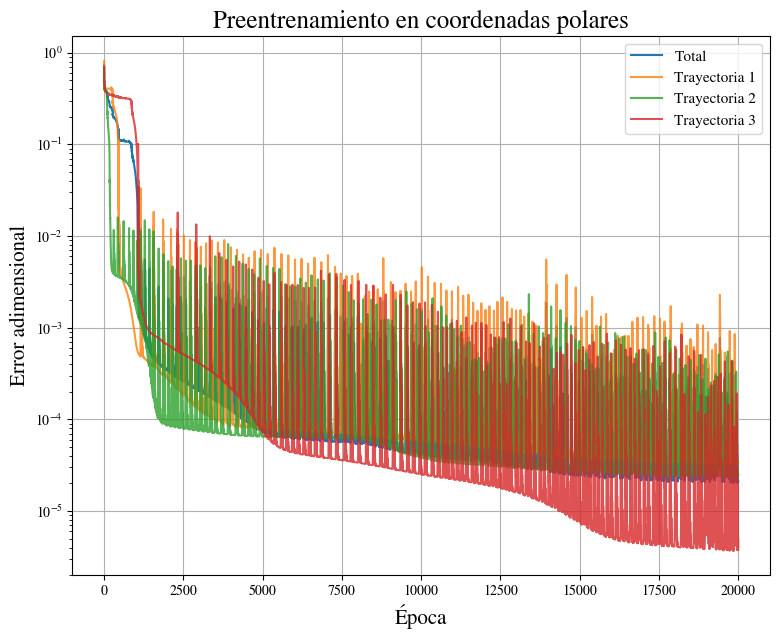

In [14]:
plt.figure(
    figsize=(9, 7)
)


plt.plot(
    loss_pre,
    label="Total"
)


for i, perdida in enumerate(
    loss_pre_individual,
    start=1
):

    plt.plot(
        perdida,
        label=f"Trayectoria {i}",
        alpha=0.8
    )


plt.xlabel("Época")
plt.ylabel("Error adimensional")
plt.yscale("log")
plt.title("Preentrenamiento en coordenadas polares")
plt.legend()

plt.show()


## 11. Chequeo previo a la PINN


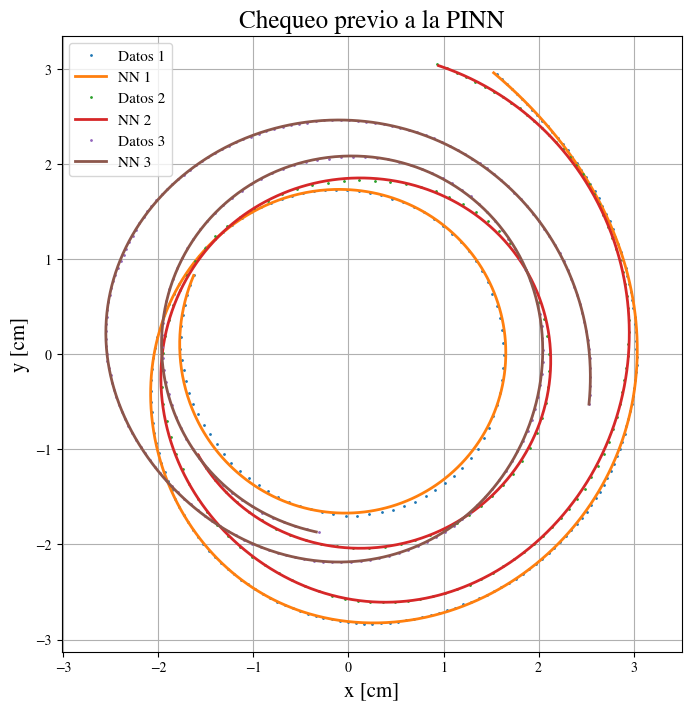

In [15]:
fig, ax = plt.subplots(
    figsize=(8, 8)
)


for i, (
    pinn,
    df,
    datos
) in enumerate(
    zip(
        pinns,
        dfs,
        datos_torch
    ),
    start=1
):

    tau_eval = torch.linspace(
        -1,
        1,
        1500,
        device=device
    ).view(-1, 1)


    with torch.no_grad():

        X_estim, _, _ = (
            salida_trayectoria(
                pinn,
                tau_eval,
                datos
            )
        )


        X_estim = (
            X_estim
            .cpu()
            .numpy()
        )


    ax.plot(
        100 * df["x_m"],
        100 * df["y_m"],
        ".",
        ms=2,
        label=f"Datos {i}"
    )


    ax.plot(
        100 * X_estim[:, 0],
        100 * X_estim[:, 1],
        lw=2,
        label=f"NN {i}"
    )


ax.set_xlabel("x [cm]")
ax.set_ylabel("y [cm]")
ax.set_title("Chequeo previo a la PINN")
ax.axis("equal")
ax.legend()

plt.show()


## 12. Error espacial del preentrenamiento


In [16]:
errores_pre_mm = []


for i, (
    pinn,
    datos
) in enumerate(
    zip(
        pinns,
        datos_torch
    ),
    start=1
):

    with torch.no_grad():

        X_pred, _, _ = (
            salida_trayectoria(
                pinn,
                datos["tau"],
                datos
            )
        )


        error = torch.sqrt(
            torch.mean(
                torch.sum(
                    (
                        X_pred
                        - datos["X"]
                    )**2,
                    dim=1
                )
            )
        )


    error_mm = (
        1000
        * error.item()
    )


    errores_pre_mm.append(
        error_mm
    )


    print(
        f"Trayectoria {i}: "
        f"RMSE espacial = "
        f"{error_mm:.3f} mm"
    )


Trayectoria 1: RMSE espacial = 0.222 mm
Trayectoria 2: RMSE espacial = 0.222 mm
Trayectoria 3: RMSE espacial = 0.108 mm


## 13. Parámetros físicos compartidos

Se conserva el modelo estándar de Burgers, con flujo radial hacia el centro.

El parámetro radial y el radio característico se restringen a valores positivos.

El centro del vórtice puede corregirse durante el entrenamiento, pero como máximo 1 cm respecto del origen de los CSV.


In [17]:
def inv_softplus(
    valor
):

    valor = torch.tensor(
        valor,
        dtype=torch.get_default_dtype()
    )

    return torch.log(
        torch.expm1(
            valor
        )
    )


CENTRO_MAX = 0.01


class ParametrosVortice(
    torch.nn.Module
):

    def __init__(
        self
    ):

        super().__init__()


        self.alp_raw = (
            torch.nn.Parameter(
                inv_softplus(
                    0.05
                )
                .clone()
                .detach()
                .view(1)
            )
        )


        self.Gam = (
            torch.nn.Parameter(
                torch.tensor([
                    0.008
                ])
            )
        )


        self.r0_raw = (
            torch.nn.Parameter(
                inv_softplus(
                    0.010
                )
                .clone()
                .detach()
                .view(1)
            )
        )


        self.xc_raw = (
            torch.nn.Parameter(
                torch.tensor([
                    0.0
                ])
            )
        )


        self.yc_raw = (
            torch.nn.Parameter(
                torch.tensor([
                    0.0
                ])
            )
        )


    @property
    def alp(
        self
    ):

        return (
            torch.nn.functional.softplus(
                self.alp_raw
            )
        )


    @property
    def r0(
        self
    ):

        return (
            torch.nn.functional.softplus(
                self.r0_raw
            )
        )


    @property
    def xc(
        self
    ):

        return (
            CENTRO_MAX
            * torch.tanh(
                self.xc_raw
            )
        )


    @property
    def yc(
        self
    ):

        return (
            CENTRO_MAX
            * torch.tanh(
                self.yc_raw
            )
        )


parametros = (
    ParametrosVortice()
    .to(device)
)


## 14. Campo de velocidades de Burgers


In [18]:
def velocidad_burgers(
    X,
    parametros
):

    x = X[:, 0]
    y = X[:, 1]


    xr = (
        x
        - parametros.xc
    )

    yr = (
        y
        - parametros.yc
    )


    r2 = (
        xr**2
        + yr**2
        + 1e-12
    )


    comun = (
        parametros.Gam
        / (
            2
            * torch.pi
            * r2
        )
        * (
            1
            - torch.exp(
                -r2
                / parametros.r0**2
            )
        )
    )


    vx = (
        -parametros.alp
        * xr
        - yr
        * comun
    )


    vy = (
        -parametros.alp
        * yr
        + xr
        * comun
    )


    return torch.stack(
        (
            vx,
            vy
        ),
        dim=1
    )


## 15. Etapa 2: entrenamiento de la PINN

La red parte del preentrenamiento.

La importancia de la ecuación física crece gradualmente durante las primeras épocas.

Esto reduce el riesgo de que Burgers arrastre inmediatamente las trayectorias lejos de los datos experimentales.


In [19]:
ITERACIONES_PINN = 20000

N_FISICA = 500

WARMUP_FISICA = 5000


optimizer = torch.optim.AdamW(
    list(
        pinns.parameters()
    )
    + list(
        parametros.parameters()
    ),
    lr=2e-4,
    weight_decay=1e-9
)


scheduler = (
    torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=1500,
        min_lr=1e-6
    )
)


tau_physics = [
    torch.linspace(
        -1,
        1,
        N_FISICA,
        device=device
    )
    .view(-1, 1)
    .requires_grad_(True)

    for _ in range(
        len(pinns)
    )
]


loss_array = []

error_datos_array = []

error_fisica_array = []

lambda_array = []


for epoch in range(
    ITERACIONES_PINN
):

    optimizer.zero_grad()


    error_datos = 0.0

    error_fisica = 0.0


    for (
        pinn,
        datos,
        tau_f
    ) in zip(
        pinns,
        datos_torch,
        tau_physics
    ):

        # --------------------------------------------
        # ERROR DE DATOS
        # --------------------------------------------

        X_pred, r_pred, dtheta_pred = (
            salida_trayectoria(
                pinn,
                datos["tau"],
                datos
            )
        )


        error_r = torch.mean(
            (
                (
                    r_pred
                    - datos["r"]
                )
                / R_SCALE
            )**2
        )


        error_theta = torch.mean(
            (
                (
                    dtheta_pred
                    - datos[
                        "delta_theta"
                    ]
                )
                / THETA_SCALE
            )**2
        )


        error_xy = torch.mean(
            (
                (
                    X_pred
                    - datos["X"]
                )
                / R_SCALE
            )**2
        )


        error_datos_i = (
            error_r
            + error_theta
            + 0.5
            * error_xy
        )


        error_datos = (
            error_datos
            + error_datos_i
        )


        # --------------------------------------------
        # ERROR DE FÍSICA
        # --------------------------------------------

        X_f, _, _ = (
            salida_trayectoria(
                pinn,
                tau_f,
                datos
            )
        )


        x_f = X_f[:, 0]

        y_f = X_f[:, 1]


        dx_dtau = (
            torch.autograd.grad(
                x_f,
                tau_f,
                torch.ones_like(
                    x_f
                ),
                create_graph=True
            )[0]
        )


        dy_dtau = (
            torch.autograd.grad(
                y_f,
                tau_f,
                torch.ones_like(
                    y_f
                ),
                create_graph=True
            )[0]
        )


        factor_tiempo = (
            2.0
            / datos["T"]
        )


        dX_dt = torch.cat(
            (
                dx_dtau
                * factor_tiempo,

                dy_dtau
                * factor_tiempo
            ),
            dim=1
        )


        velocidad = (
            velocidad_burgers(
                X_f,
                parametros
            )
        )


        error_fisica_i = (
            torch.mean(
                (
                    (
                        dX_dt
                        - velocidad
                    )
                    / U_SCALE
                )**2
            )
        )


        error_fisica = (
            error_fisica
            + error_fisica_i
        )


    error_datos = (
        error_datos
        / len(pinns)
    )


    error_fisica = (
        error_fisica
        / len(pinns)
    )


    lambda_fisica = min(
        1.0,
        epoch
        / WARMUP_FISICA
    )


    loss = (
        error_datos
        + lambda_fisica
        * error_fisica
    )


    loss.backward()


    torch.nn.utils.clip_grad_norm_(
        list(
            pinns.parameters()
        )
        + list(
            parametros.parameters()
        ),
        max_norm=5.0
    )


    optimizer.step()


    scheduler.step(
        loss.detach()
    )


    loss_array.append(
        loss.detach()
        .cpu()
        .item()
    )


    error_datos_array.append(
        error_datos.detach()
        .cpu()
        .item()
    )


    error_fisica_array.append(
        error_fisica.detach()
        .cpu()
        .item()
    )


    lambda_array.append(
        lambda_fisica
    )


    if epoch % 1000 == 0:

        print(
            f"Época {epoch:5d} | "
            f"Datos = "
            f"{error_datos.item():.3e} | "
            f"Física = "
            f"{error_fisica.item():.3e} | "
            f"lambda = "
            f"{lambda_fisica:.2f}"
        )


Época     0 | Datos = 2.121e-05 | Física = 2.734e-02 | lambda = 0.00
Época  1000 | Datos = 4.756e-04 | Física = 8.105e-03 | lambda = 0.20
Época  2000 | Datos = 1.200e-03 | Física = 5.432e-03 | lambda = 0.40
Época  3000 | Datos = 1.795e-03 | Física = 4.136e-03 | lambda = 0.60
Época  4000 | Datos = 2.271e-03 | Física = 3.418e-03 | lambda = 0.80
Época  5000 | Datos = 2.660e-03 | Física = 2.963e-03 | lambda = 1.00
Época  6000 | Datos = 2.661e-03 | Física = 2.951e-03 | lambda = 1.00
Época  7000 | Datos = 2.660e-03 | Física = 2.947e-03 | lambda = 1.00
Época  8000 | Datos = 2.659e-03 | Física = 2.944e-03 | lambda = 1.00
Época  9000 | Datos = 2.659e-03 | Física = 2.941e-03 | lambda = 1.00
Época 10000 | Datos = 2.658e-03 | Física = 2.940e-03 | lambda = 1.00
Época 11000 | Datos = 2.658e-03 | Física = 2.939e-03 | lambda = 1.00
Época 12000 | Datos = 2.658e-03 | Física = 2.939e-03 | lambda = 1.00
Época 13000 | Datos = 2.657e-03 | Física = 2.938e-03 | lambda = 1.00
Época 14000 | Datos = 2.657e-03 | 

## 16. Evolución de las pérdidas


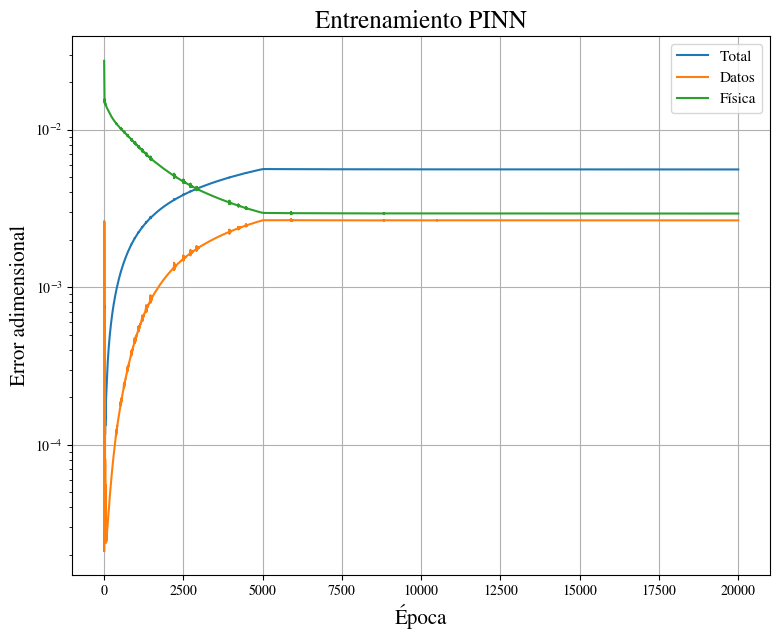

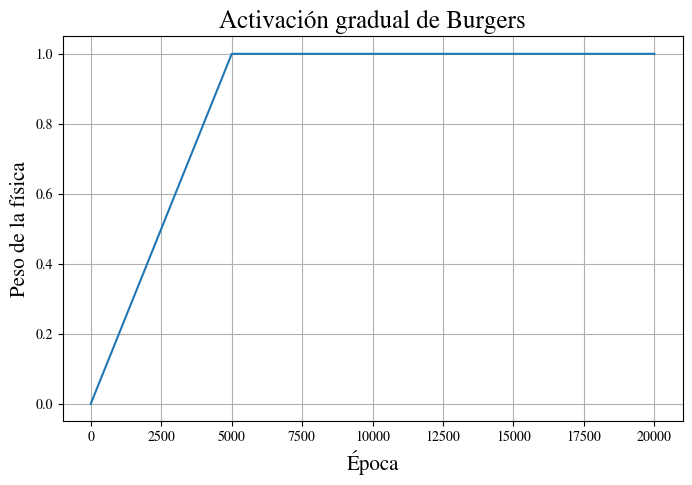

In [20]:
plt.figure(
    figsize=(9, 7)
)


plt.plot(
    loss_array,
    label="Total"
)


plt.plot(
    error_datos_array,
    label="Datos"
)


plt.plot(
    error_fisica_array,
    label="Física"
)


plt.xlabel("Época")
plt.ylabel("Error adimensional")
plt.yscale("log")
plt.title("Entrenamiento PINN")
plt.legend()

plt.show()


plt.figure(
    figsize=(8, 5)
)


plt.plot(
    lambda_array
)


plt.xlabel("Época")
plt.ylabel("Peso de la física")
plt.title("Activación gradual de Burgers")

plt.show()


## 17. Trayectorias experimentales vs PINN final


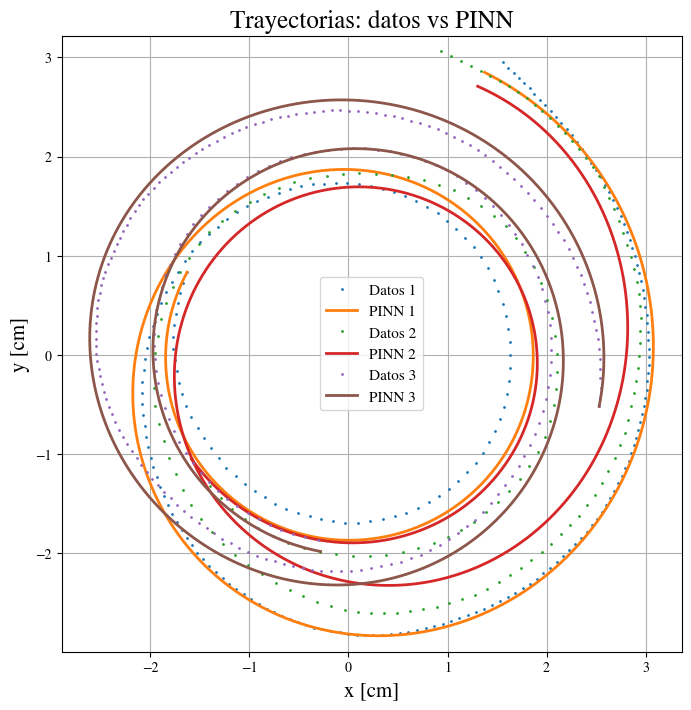

In [21]:
fig, ax = plt.subplots(
    figsize=(8, 8)
)


for i, (
    pinn,
    df,
    datos
) in enumerate(
    zip(
        pinns,
        dfs,
        datos_torch
    ),
    start=1
):

    tau_eval = torch.linspace(
        -1,
        1,
        1500,
        device=device
    ).view(-1, 1)


    with torch.no_grad():

        X_estim, _, _ = (
            salida_trayectoria(
                pinn,
                tau_eval,
                datos
            )
        )


        X_estim = (
            X_estim
            .cpu()
            .numpy()
        )


    ax.plot(
        100 * df["x_m"],
        100 * df["y_m"],
        ".",
        ms=2,
        label=f"Datos {i}"
    )


    ax.plot(
        100 * X_estim[:, 0],
        100 * X_estim[:, 1],
        lw=2,
        label=f"PINN {i}"
    )


ax.set_xlabel("x [cm]")
ax.set_ylabel("y [cm]")
ax.set_title("Trayectorias: datos vs PINN")
ax.axis("equal")
ax.legend()

plt.show()


## 18. Parámetros aprendidos


In [22]:
alpha = (
    parametros.alp
    .detach()
    .cpu()
    .item()
)


Gamma = (
    parametros.Gam
    .detach()
    .cpu()
    .item()
)


r0 = (
    parametros.r0
    .detach()
    .cpu()
    .item()
)


xc = (
    parametros.xc
    .detach()
    .cpu()
    .item()
)


yc = (
    parametros.yc
    .detach()
    .cpu()
    .item()
)


print(
    f"alpha = {alpha:.6g} 1/s"
)

print(
    f"Gamma = {Gamma:.6g} m²/s"
)

print(
    f"r0 = {r0:.6g} m"
)

print(
    f"xc = {xc:.6g} m"
)

print(
    f"yc = {yc:.6g} m"
)

print(
    f"desplazamiento del centro = "
    f"{100*np.sqrt(xc**2 + yc**2):.3f} cm"
)


alpha = 0.022886 1/s
Gamma = 0.00992492 m²/s
r0 = 0.00682656 m
xc = 0.00103282 m
yc = -0.000666915 m
desplazamiento del centro = 0.123 cm


## 19. Campo de velocidades reconstruido


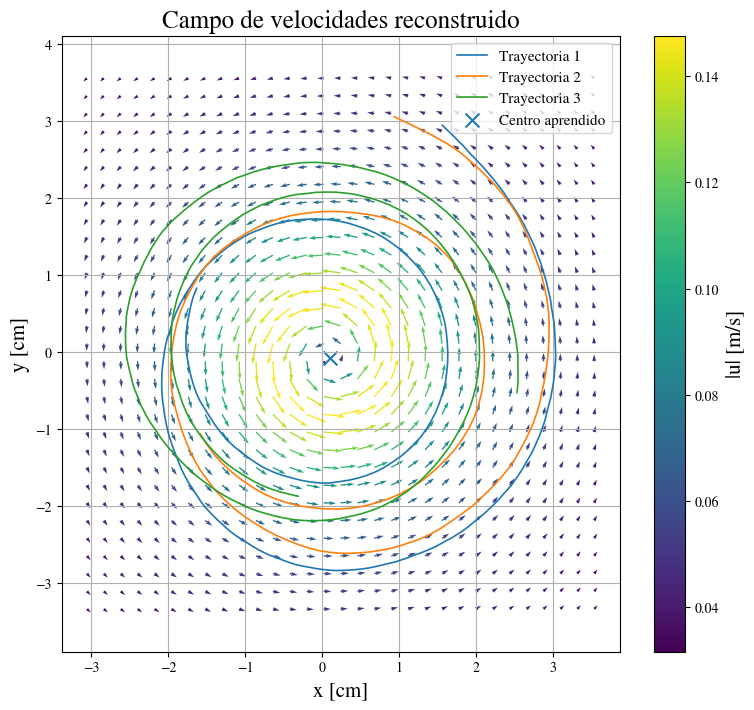

In [23]:
todos_x = np.concatenate(
    [
        df["x_m"].values
        for df in dfs
    ]
)


todos_y = np.concatenate(
    [
        df["y_m"].values
        for df in dfs
    ]
)


margen = 0.005


xmin = (
    todos_x.min()
    - margen
)

xmax = (
    todos_x.max()
    + margen
)

ymin = (
    todos_y.min()
    - margen
)

ymax = (
    todos_y.max()
    + margen
)


x_grid = np.linspace(
    xmin,
    xmax,
    31
)


y_grid = np.linspace(
    ymin,
    ymax,
    31
)


Xg, Yg = np.meshgrid(
    x_grid,
    y_grid
)


XY = torch.tensor(
    np.column_stack(
        (
            Xg.ravel(),
            Yg.ravel()
        )
    ),
    device=device
)


with torch.no_grad():

    UV = (
        velocidad_burgers(
            XY,
            parametros
        )
        .cpu()
        .numpy()
    )


Ug = UV[:, 0].reshape(
    Xg.shape
)


Vg = UV[:, 1].reshape(
    Yg.shape
)


modulo = np.sqrt(
    Ug**2
    + Vg**2
)


fig, ax = plt.subplots(
    figsize=(9, 8)
)


q = ax.quiver(
    100 * Xg,
    100 * Yg,
    Ug,
    Vg,
    modulo
)


for i, df in enumerate(
    dfs,
    start=1
):

    ax.plot(
        100 * df["x_m"],
        100 * df["y_m"],
        lw=1.2,
        label=f"Trayectoria {i}"
    )


ax.scatter(
    [100 * xc],
    [100 * yc],
    marker="x",
    s=100,
    label="Centro aprendido"
)


ax.set_xlabel("x [cm]")
ax.set_ylabel("y [cm]")
ax.set_title("Campo de velocidades reconstruido")
ax.axis("equal")
ax.legend()


cbar = plt.colorbar(
    q,
    ax=ax
)


cbar.set_label(
    "|u| [m/s]"
)


plt.show()


## 20. Perfil radial y tangencial aprendido


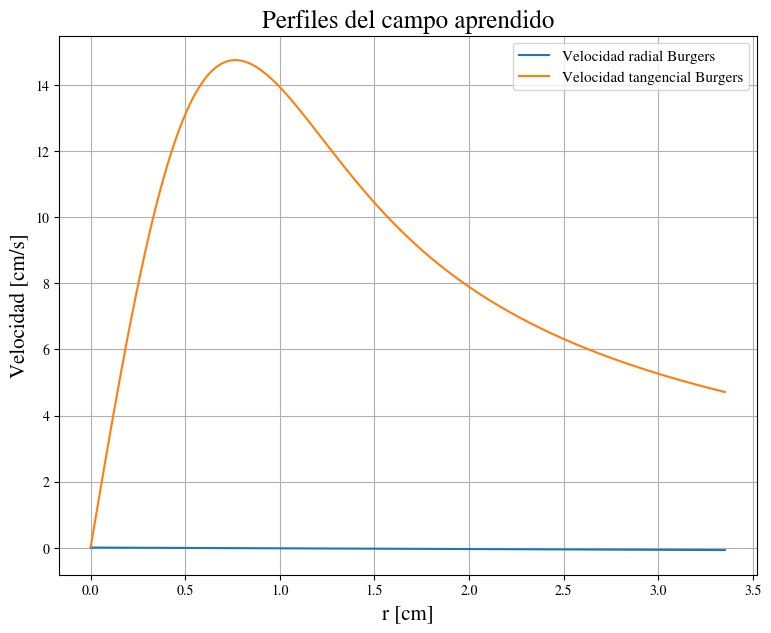

In [24]:
r_max = np.max(
    np.sqrt(
        (
            todos_x
            - xc
        )**2
        +
        (
            todos_y
            - yc
        )**2
    )
)


r = np.linspace(
    1e-5,
    r_max,
    500
)


u_r = (
    -alpha
    * r
)


u_theta = (
    Gamma
    / (
        2
        * np.pi
        * r
    )
    * (
        1
        - np.exp(
            -r**2
            / r0**2
        )
    )
)


plt.figure(
    figsize=(9, 7)
)


plt.plot(
    100 * r,
    100 * u_r,
    label="Velocidad radial Burgers"
)


plt.plot(
    100 * r,
    100 * u_theta,
    label="Velocidad tangencial Burgers"
)


plt.xlabel("r [cm]")
plt.ylabel("Velocidad [cm/s]")
plt.title("Perfiles del campo aprendido")
plt.legend()

plt.show()


## 21. Comparación del modelo aprendido con velocidades estimadas de las trayectorias

Este gráfico es especialmente importante.

Si los datos derivados de las trayectorias no se agrupan alrededor de las curvas aprendidas, el problema no se arregla simplemente entrenando más la red: puede indicar incompatibilidad entre la partícula medida y el modelo de Burgers.


In [ ]:
fig, ax = plt.subplots(
    figsize=(9, 7)
)


for i, d in enumerate(
    diagnosticos,
    start=1
):

    ax.plot(
        100 * d["r"],
        100 * d["vr"],
        ".",
        ms=3,
        alpha=0.7,
        label=f"Datos {i}"
    )


ax.plot(
    100 * r,
    100 * u_r,
    linewidth=3,
    label="Burgers PINN"
)


ax.set_xlabel("r [cm]")
ax.set_ylabel("v radial [cm/s]")
ax.set_title("Componente radial: datos vs modelo")
ax.legend()

plt.show()


fig, ax = plt.subplots(
    figsize=(9, 7)
)


for i, d in enumerate(
    diagnosticos,
    start=1
):

    ax.plot(
        100 * d["r"],
        100 * d["vt"],
        ".",
        ms=3,
        alpha=0.7,
        label=f"Datos {i}"
    )


ax.plot(
    100 * r,
    100 * u_theta,
    linewidth=3,
    label="Burgers PINN"
)


ax.set_xlabel("r [cm]")
ax.set_ylabel("v tangencial [cm/s]")
ax.set_title("Componente tangencial: datos vs modelo")
ax.legend()

plt.show()


## 22. Diagnóstico final cuantitativo


In [ ]:
print("=" * 60)
print("AJUSTE FINAL DE LAS TRAYECTORIAS")
print("=" * 60)


errores_finales_mm = []


for i, (
    pinn,
    datos
) in enumerate(
    zip(
        pinns,
        datos_torch
    ),
    start=1
):

    with torch.no_grad():

        X_pred, _, _ = (
            salida_trayectoria(
                pinn,
                datos["tau"],
                datos
            )
        )


        error = torch.sqrt(
            torch.mean(
                torch.sum(
                    (
                        X_pred
                        - datos["X"]
                    )**2,
                    dim=1
                )
            )
        )


    error_mm = (
        1000
        * error.item()
    )


    errores_finales_mm.append(
        error_mm
    )


    print(
        f"Trayectoria {i}: "
        f"RMSE espacial final = "
        f"{error_mm:.3f} mm"
    )


print()
print("=" * 60)
print("CAMBIO RESPECTO DEL PREENTRENAMIENTO")
print("=" * 60)


for i, (
    e_pre,
    e_final
) in enumerate(
    zip(
        errores_pre_mm,
        errores_finales_mm
    ),
    start=1
):

    factor = (
        e_final
        / max(
            e_pre,
            1e-12
        )
    )


    print(
        f"Trayectoria {i}: "
        f"pre = {e_pre:.3f} mm | "
        f"final = {e_final:.3f} mm | "
        f"factor = {factor:.2f}"
    )


    if factor > 2:

        print(
            "  ADVERTENCIA: la física está "
            "empeorando mucho el ajuste a los datos."
        )


print()
print("=" * 60)
print("INTERPRETACIÓN")
print("=" * 60)


fracciones_salida = [
    np.mean(
        d["vr"] > 0
    )
    for d in diagnosticos
]


if np.mean(
    fracciones_salida
) > 0.65:

    print(
        "ADVERTENCIA FÍSICA: las trayectorias "
        "medidas presentan mayormente velocidad "
        "radial saliente respecto del origen usado, "
        "mientras que Burgers estándar con alpha > 0 "
        "predice velocidad radial entrante."
    )


if np.sqrt(
    xc**2 + yc**2
) > 0.008:

    print(
        "ADVERTENCIA: el centro aprendido quedó "
        "muy cerca del límite permitido. Puede estar "
        "intentando compensar una incompatibilidad "
        "entre datos y modelo."
    )


print(
    "Si las trayectorias se ajustan bien antes de "
    "activar la física pero se separan mucho después, "
    "la limitación principal probablemente sea el "
    "modelo físico o el trazador, no la capacidad "
    "de la red neuronal."
)
